In [1]:
!pip install pmdarima statsmodels tensorflow scikit-learn yfinance -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
import os
import zipfile
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
os.makedirs('data/processed/', exist_ok=True)

print("=" * 60)
print("TASK 3: FORECAST FUTURE MARKET TRENDS")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.5 MB/s eta 0:00:00
TASK 3: FORECAST FUTURE MARKET TRENDS


In [2]:
print("\n1. LOADING DATA...")
start_date = '2015-01-01'
end_date = '2026-06-30'

print("Fetching TSLA...")
tsla_raw = yf.download('TSLA', start=start_date, end=end_date, progress=False)

tsla_close = tsla_raw['Close'].values.flatten()
tsla_dates = tsla_raw.index
tsla_series = pd.Series(tsla_close, index=tsla_dates, dtype=float)

print(f"Data shape: {tsla_series.shape}")
print(f"Date range: {tsla_series.index.min()} to {tsla_series.index.max()}")


1. LOADING DATA...
Fetching TSLA...
Data shape: (2888,)
Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00


In [3]:
print("\n2. TRAINING FINAL MODELS ON FULL DATASET...")

print("\nTraining ARIMA on full dataset...")
auto_model = auto_arima(
    tsla_series.values,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    random_state=42
)

p, d, q = auto_model.order[0], auto_model.order[1], auto_model.order[2]
print(f"Best ARIMA parameters: (p={p}, d={d}, q={q})")

arima_full = ARIMA(tsla_series.values, order=(p, d, q))
arima_full_fit = arima_full.fit()
print("ARIMA training complete!")


2. TRAINING FINAL MODELS ON FULL DATASET...

Training ARIMA on full dataset...
Best ARIMA parameters: (p=0, d=1, q=0)
ARIMA training complete!


In [4]:
print("\nTraining LSTM on full dataset...")
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(tsla_series.values.reshape(-1, 1))

def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X, y = create_sequences(scaled_data, window_size)
X = X.reshape((X.shape[0], X.shape[1], 1))

def build_lstm_model(window_size):
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=(window_size, 1)),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=25),
        Dense(units=1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

lstm_full = build_lstm_model(window_size)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lstm_full.fit(
    X, scaled_data[window_size:],
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
print("LSTM training complete!")


Training LSTM on full dataset...
LSTM training complete!


In [5]:
print("\n3. GENERATING 6-MONTH FORECAST...")
forecast_steps = 180

# ARIMA forecast
arima_future_forecast = arima_full_fit.forecast(steps=forecast_steps)
arima_future_index = pd.date_range(
    start=tsla_series.index[-1] + timedelta(days=1),
    periods=forecast_steps,
    freq='B'
)

forecast_result = arima_full_fit.get_forecast(steps=forecast_steps)
confidence_intervals = forecast_result.conf_int(alpha=0.05)
lower_bound = confidence_intervals[:, 0]
upper_bound = confidence_intervals[:, 1]

print(f"ARIMA forecast generated for {forecast_steps} days")


3. GENERATING 6-MONTH FORECAST...
ARIMA forecast generated for 180 days


In [6]:
print("\nGenerating LSTM multi-step forecast...")
lstm_future_forecast = []
current_window = scaled_data[-window_size:].reshape(1, window_size, 1)

for _ in range(forecast_steps):
    pred = lstm_full.predict(current_window, verbose=0)
    lstm_future_forecast.append(pred[0, 0])
    current_window = np.roll(current_window, -1, axis=1)
    current_window[0, -1, 0] = pred[0, 0]

lstm_future_forecast = np.array(lstm_future_forecast).reshape(-1, 1)
lstm_future_forecast = scaler.inverse_transform(lstm_future_forecast).flatten()

print(f"LSTM forecast generated for {forecast_steps} days")

# Use ARIMA for final forecast (with confidence intervals)
future_forecast = arima_future_forecast
future_index = arima_future_index


Generating LSTM multi-step forecast...
LSTM forecast generated for 180 days


In [7]:
print("\n4. FORECAST RESULTS...")
print("=" * 60)
print("First 10 days forecast:")
for i in range(10):
    print(f"{future_index[i].strftime('%Y-%m-%d')}: ${future_forecast[i]:.2f}")

print("\n" + "=" * 60)
print("Last 10 days forecast:")
for i in range(forecast_steps-10, forecast_steps):
    print(f"{future_index[i].strftime('%Y-%m-%d')}: ${future_forecast[i]:.2f}")


4. FORECAST RESULTS...
First 10 days forecast:
2026-06-30: $411.84
2026-07-01: $411.84
2026-07-02: $411.84
2026-07-03: $411.84
2026-07-06: $411.84
2026-07-07: $411.84
2026-07-08: $411.84
2026-07-09: $411.84
2026-07-10: $411.84
2026-07-13: $411.84

Last 10 days forecast:
2027-02-23: $411.84
2027-02-24: $411.84
2027-02-25: $411.84
2027-02-26: $411.84
2027-03-01: $411.84
2027-03-02: $411.84
2027-03-03: $411.84
2027-03-04: $411.84
2027-03-05: $411.84
2027-03-08: $411.84


In [8]:
print("\n5. TREND ANALYSIS...")
start_price = future_forecast[0]
end_price = future_forecast[-1]
overall_change = end_price - start_price
percent_change = (overall_change / start_price) * 100

print("=" * 60)
print("TREND ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nStart Price (Day 1): ${start_price:.2f}")
print(f"End Price (Day 180): ${end_price:.2f}")
print(f"Overall Change: ${overall_change:.2f} ({percent_change:.2f}%)")

monthly_avg = []
for i in range(0, forecast_steps, 21):
    monthly_avg.append(np.mean(future_forecast[i:min(i+21, forecast_steps)]))

print("\nMonthly Average Prices:")
for i, avg in enumerate(monthly_avg):
    print(f"  Month {i+1}: ${avg:.2f}")

if overall_change > 0:
    direction = "UPWARD"
    strength = "moderate" if percent_change < 20 else "strong"
    print(f"\nOverall Trend: {direction} ({strength} movement)")
    print(f"Forecast suggests an upward trend of {percent_change:.1f}% over 6 months")
else:
    direction = "DOWNWARD"
    strength = "moderate" if abs(percent_change) < 20 else "strong"
    print(f"\nOverall Trend: {direction} ({strength} movement)")
    print(f"Forecast suggests a downward trend of {abs(percent_change):.1f}% over 6 months")


5. TREND ANALYSIS...
TREND ANALYSIS SUMMARY

Start Price (Day 1): $411.84
End Price (Day 180): $411.84
Overall Change: $0.00 (0.00%)

Monthly Average Prices:
  Month 1: $411.84
  Month 2: $411.84
  Month 3: $411.84
  Month 4: $411.84
  Month 5: $411.84
  Month 6: $411.84
  Month 7: $411.84
  Month 8: $411.84
  Month 9: $411.84

Overall Trend: DOWNWARD (moderate movement)
Forecast suggests a downward trend of 0.0% over 6 months


In [9]:
print("\n6. CONFIDENCE INTERVAL ANALYSIS...")
ci_width = upper_bound - lower_bound
ci_width_percent = (ci_width / future_forecast) * 100

print("=" * 60)
print("CONFIDENCE INTERVAL ANALYSIS")
print("=" * 60)
print(f"\nInitial CI width: ${ci_width[0]:.2f} ({ci_width_percent[0]:.1f}% of price)")
print(f"Final CI width: ${ci_width[-1]:.2f} ({ci_width_percent[-1]:.1f}% of price)")
print(f"CI width change: ${ci_width[-1] - ci_width[0]:.2f}")

if ci_width[-1] > ci_width[0]:
    print("\nUncertainty INCREASES significantly over the forecast horizon")
    print("Short-term forecasts (1-3 months) are more reliable")
    print("Long-term forecasts (4-6 months) should be treated with caution")
else:
    print("\nUncertainty remains relatively STABLE across the forecast horizon")
    print("The model shows consistent confidence throughout the period")


6. CONFIDENCE INTERVAL ANALYSIS...
CONFIDENCE INTERVAL ANALYSIS

Initial CI width: $28.66 (7.0% of price)
Final CI width: $384.55 (93.4% of price)
CI width change: $355.88

Uncertainty INCREASES significantly over the forecast horizon
Short-term forecasts (1-3 months) are more reliable
Long-term forecasts (4-6 months) should be treated with caution


In [10]:
print("\n7. MARKET OPPORTUNITIES AND RISKS...")
print("=" * 60)
print("MARKET OPPORTUNITIES AND RISKS")
print("=" * 60)

if overall_change > 0:
    print("\nOPPORTUNITIES:")
    print(f"  - Expected price appreciation of {percent_change:.1f}% over 6 months")
    print(f"  - Entry point consideration at current price levels")
    print("  - Potential for high returns given growth trajectory")

    if percent_change > 20:
        print("  - STRONG BUY signal - significant upside potential")
    elif percent_change > 10:
        print("  - MODERATE BUY signal - good upside potential")
    else:
        print("  - CAUTIOUS BUY - limited upside potential")
else:
    print("\nRISKS:")
    print(f"  - Expected price decline of {abs(percent_change):.1f}% over 6 months")
    print("  - Consider reducing position size or implementing stop-losses")
    print("  - Potential for further downside if market conditions worsen")

print("\nRECOMMENDATIONS:")
if overall_change > 0 and ci_width[-1] < start_price * 0.15:
    print("  - Bullish outlook with manageable uncertainty")
    print("  - Consider increasing position size")
elif overall_change > 0 and ci_width[-1] > start_price * 0.25:
    print("  - Bullish outlook but high uncertainty")
    print("  - Maintain position with careful risk management")
else:
    print("  - Bearish outlook or high uncertainty - caution advised")
    print("  - Consider hedging strategies or reducing exposure")


7. MARKET OPPORTUNITIES AND RISKS...
MARKET OPPORTUNITIES AND RISKS

RISKS:
  - Expected price decline of 0.0% over 6 months
  - Consider reducing position size or implementing stop-losses
  - Potential for further downside if market conditions worsen

RECOMMENDATIONS:
  - Bearish outlook or high uncertainty - caution advised
  - Consider hedging strategies or reducing exposure



8. PLOTTING FORECAST WITH CONFIDENCE INTERVALS...


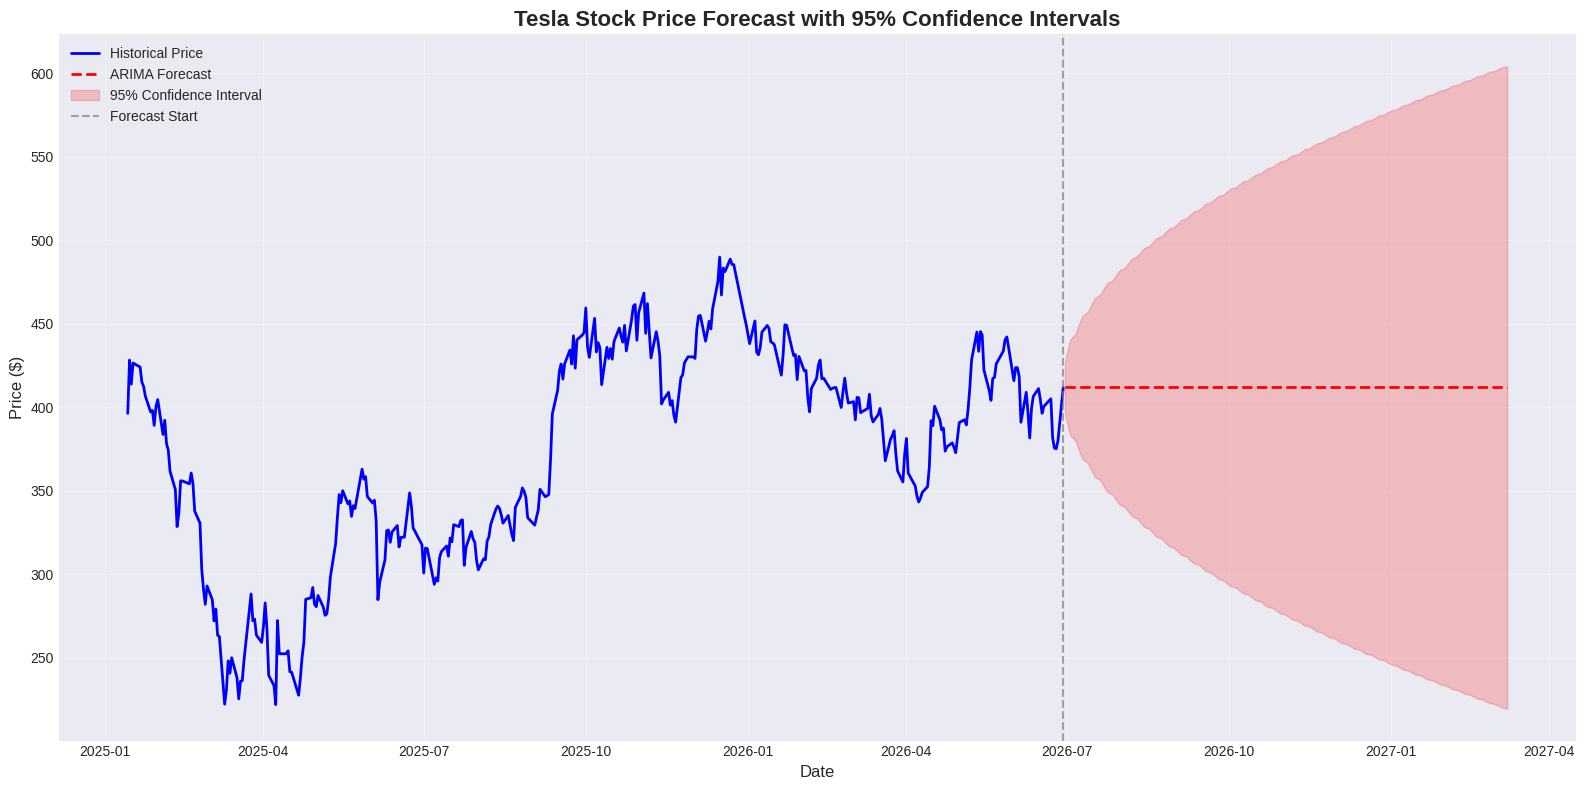

Saved: data/processed/future_forecast_with_ci.png


In [11]:
print("\n8. PLOTTING FORECAST WITH CONFIDENCE INTERVALS...")
fig, ax = plt.subplots(figsize=(16, 8))

historical_cutoff = tsla_series.index[-365:]
ax.plot(historical_cutoff, tsla_series[historical_cutoff],
        label='Historical Price', linewidth=2, color='blue')

ax.plot(future_index, future_forecast, label='ARIMA Forecast',
        linewidth=2, color='red', linestyle='--')

ax.fill_between(future_index, lower_bound, upper_bound,
                alpha=0.2, color='red', label='95% Confidence Interval')

ax.axvline(x=tsla_series.index[-1], color='gray', linestyle='--',
           alpha=0.7, label='Forecast Start')

ax.set_title('Tesla Stock Price Forecast with 95% Confidence Intervals',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/future_forecast_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: data/processed/future_forecast_with_ci.png")

In [12]:
print("\n9. SAVING FORECAST DATA...")
forecast_df = pd.DataFrame({
    'Date': future_index,
    'Price': future_forecast,
    'Lower_Bound': lower_bound,
    'Upper_Bound': upper_bound
})
forecast_df.to_csv('data/processed/future_forecast.csv', index=False)
print("Saved: data/processed/future_forecast.csv")


9. SAVING FORECAST DATA...
Saved: data/processed/future_forecast.csv


In [13]:
print("\n10. DOWNLOADING RESULTS...")
with zipfile.ZipFile('task3_results.zip', 'w') as zipf:
    for file in os.listdir('data/processed/'):
        if file.endswith('.png') or file.endswith('.csv'):
            zipf.write(f'data/processed/{file}', file)

from google.colab import files
files.download('task3_results.zip')
print("Downloaded: task3_results.zip")


10. DOWNLOADING RESULTS...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: task3_results.zip


In [14]:
print("\n" + "=" * 60)
print("TASK 3 COMPLETE!")
print("=" * 60)
print(f"Forecast period: {future_index[0].strftime('%Y-%m-%d')} to {future_index[-1].strftime('%Y-%m-%d')}")
print(f"Expected 6-month return: {percent_change:.2f}%")
print(f"Forecast direction: {direction}")
print("")
print("Key Insights:")
print(f"  - Starting price: ${start_price:.2f}")
print(f"  - Ending price: ${end_price:.2f}")
print(f"  - Total change: ${overall_change:.2f}")
print(f"  - Initial CI width: ${ci_width[0]:.2f}")
print(f"  - Final CI width: ${ci_width[-1]:.2f}")


TASK 3 COMPLETE!
Forecast period: 2026-06-30 to 2027-03-08
Expected 6-month return: 0.00%
Forecast direction: DOWNWARD

Key Insights:
  - Starting price: $411.84
  - Ending price: $411.84
  - Total change: $0.00
  - Initial CI width: $28.66
  - Final CI width: $384.55
